# Medical Insurance Charges Prediction Using Machine Learning

## Project Overview

Medical insurance charges can vary considerably between individuals based on demographic, lifestyle, and health-related characteristics. Understanding the factors associated with these differences and developing reliable predictive models can support data-driven analysis of healthcare costs.

This project applies exploratory data analysis (EDA), data preprocessing, visualization, and machine learning techniques to investigate the factors associated with medical insurance charges and to develop models capable of predicting insurance charges from individual characteristics.

---

## Problem Statement

Medical insurance costs vary across individuals, but the extent to which characteristics such as age, BMI, smoking status, number of children, sex, and region contribute to these differences is not always immediately apparent.

This project therefore investigates patterns within the available insurance dataset and develops predictive models to estimate medical insurance charges based on the available characteristics.

---

## Project Objectives

The objectives of this project are to:

1. Explore the structure and characteristics of the insurance dataset.
2. Clean and prepare the data for analysis and machine learning.
3. Investigate the distribution of medical insurance charges.
4. Examine relationships between insurance charges and variables such as age, BMI, smoking status, sex, children, and region.
5. Identify the variables that contribute most strongly to model predictions.
6. Develop a Linear Regression model as an interpretable baseline.
7. Develop a Random Forest Regression model to capture nonlinear relationships.
8. Evaluate and compare model performance using MAE, RMSE, R², and cross-validation.
9. Interpret the findings and identify limitations of the analysis.

---

## Dataset Variables

The dataset contains the following main variables:

| Variable | Description |
|---|---|
| `age` | Age of the individual |
| `sex` | Sex category recorded in the dataset |
| `bmi` | Body Mass Index |
| `children` | Number of children/dependents recorded |
| `smoker` | Smoking status |
| `region` | Residential region |
| `charges` | Medical insurance charges |

Additional variables such as `bmi_category` and `age_group` were created during the analysis to support exploratory analysis and visualization.

---

## Methodology

The project follows the general data science workflow:

**Data Collection → Data Understanding → Data Cleaning → Exploratory Data Analysis → Feature Engineering → Data Encoding → Train-Test Split → Model Development → Model Evaluation → Cross-Validation → Interpretation**

Two machine learning regression models are evaluated:

- **Linear Regression**
- **Random Forest Regression**

Model performance is assessed using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score
- 5-Fold Cross-Validation

---

## Tools and Technologies

- Python
- Jupyter Notebook
- Pandas
- NumPy
- Matplotlib
- Scikit-learn

---

## Key Model Results

The Linear Regression model achieved an R² score of approximately **0.807** on the test dataset, while the Random Forest Regression model achieved approximately **0.880**.

Using 5-fold cross-validation, Linear Regression achieved an average R² of approximately **0.747**, while Random Forest achieved approximately **0.836**.

The modelling results also showed that smoking status had the strongest predictive contribution, while BMI and age were also important variables.

> **Note:** The results describe statistical associations and predictive relationships within this dataset. They should not be interpreted as evidence of causal relationships.

## BUSINESS PROBLEM


UrbanNest Health Analytics works with health insurance providers to understand how individual characteristics influence medical insurance costs. The company currently faces inconsistencies in estimating insurance charges, which can result in customers being overcharged or undercharged.

The objective of this project is to analyze individual characteristics such as age, BMI, smoking status, number of children, sex, and region, and build a Linear Regression model that predicts medical insurance charges.

Accurate prediction of insurance charges can support more consistent pricing, improve business decision-making, and provide better insights into the factors associated with medical insurance costs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('C:/Users/USER/Downloads/archive+/insurance.csv')

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.shape

(1338, 7)

In [5]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [6]:
df.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
df.tail(5)

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [10]:
df.describe(include="object")

C:\Users\USER\AppData\Local\Temp\ipykernel_5452\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


In [11]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(1)

In [13]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [14]:
df_clean = df.copy()

In [15]:
df_clean.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Observation: The dataset contains no missing values; therefore, no missing-value treatment is required.

In [16]:
df_clean.duplicated().sum()

np.int64(1)

In [17]:
df_clean[df_clean.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [18]:
df_clean.duplicated().sum()

np.int64(1)

In [19]:
df_clean.drop_duplicates(inplace=True)

In [20]:
df_clean.duplicated().sum()

np.int64(0)

In [21]:
df_clean.reset_index(drop=True, inplace=True)

In [22]:
df_clean["sex"].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [23]:
df_clean["smoker"].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [24]:
df_clean["region"].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [25]:
for column in ["sex", "smoker", "region"]:
    print(f"\n{column.upper()}")
    print(df_clean[column].value_counts())


SEX
sex
male      675
female    662
Name: count, dtype: int64

SMOKER
smoker
no     1063
yes     274
Name: count, dtype: int64

REGION
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


In [26]:
df_clean[["age", "bmi", "children", "charges"]].describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [27]:
df_clean.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [28]:
print("Dataset shape:", df_clean.shape)
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())

df_clean.head()

Dataset shape: (1337, 7)
Missing values: 0
Duplicate rows: 0


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Data Cleaning Summary

The dataset was checked for missing values, duplicate records, inconsistent categorical values, incorrect data types, and potentially invalid numerical values. No missing values were identified. Duplicate records were inspected and removed where appropriate. The categorical variables were also examined for inconsistencies, while the numerical variables were reviewed using descriptive statistics. The resulting dataset was retained for exploratory data analysis.

In [29]:
df_clean.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [30]:
df_clean.describe(include="object")

C:\Users\USER\AppData\Local\Temp\ipykernel_5452\592941607.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_clean.describe(include="object")


,sex,smoker,region
count,1337,1337,1337
unique,2,2,4
top,male,no,southeast
freq,675,1063,364


Purpose: Descriptive statistics provide an overview of the numerical and categorical variables in the dataset before investigating individual relationships.

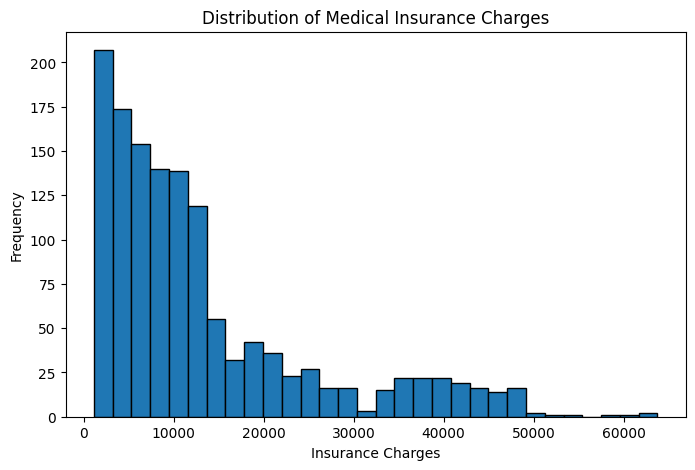

In [31]:
plt.figure(figsize=(8, 5))

plt.hist(df_clean["charges"], bins=30, edgecolor="black")

plt.title("Distribution of Medical Insurance Charges")
plt.xlabel("Insurance Charges")
plt.ylabel("Frequency")

plt.show()

Interpretation: The distribution of medical insurance charges is right-skewed (positively skewed). Most customers have relatively lower insurance charges, with a large proportion falling below approximately $15,000. However, a smaller number of customers have much higher charges, extending beyond $60,000. This suggests that while most individuals incur relatively lower medical insurance costs, a smaller group has substantially higher costs.

In [32]:
smoker_charges = (
    df_clean.groupby("smoker")["charges"]
    .mean()
    .sort_values(ascending=False)
)

smoker_charges

smoker
yes    32050.231832
no      8440.660307
Name: charges, dtype: float64

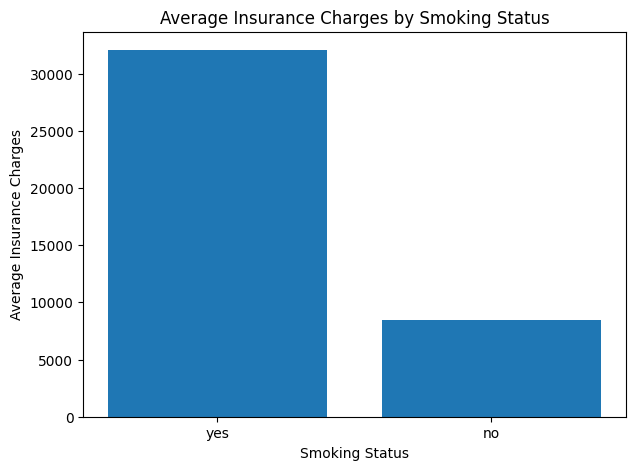

In [33]:
plt.figure(figsize=(7, 5))

plt.bar(smoker_charges.index, smoker_charges.values)

plt.title("Average Insurance Charges by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Average Insurance Charges")

plt.show()

Interpretation: The analysis shows a substantial difference in average medical insurance charges between smokers and non-smokers. Smokers have an average insurance charge of approximately $32,050, compared with approximately $8,441 for non-smokers. This means that the average charge for smokers is about 3.8 times higher than that of non-smokers. This suggests that smoking status has a strong relationship with medical insurance charges in this dataset and may be an important predictor when building the Linear Regression model.

However, this comparison shows an association and does not by itself establish that smoking is the sole cause of the higher charges, since other factors such as age and BMI may also contribute.

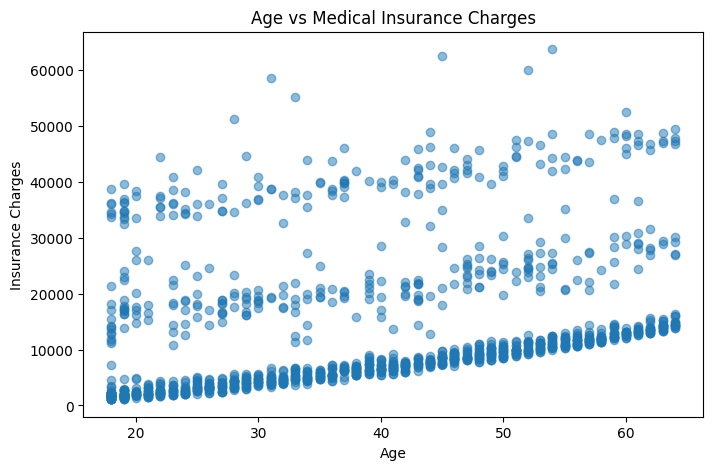

In [34]:
plt.figure(figsize=(8, 5))

plt.scatter(df_clean["age"], df_clean["charges"], alpha=0.5)

plt.title("Age vs Medical Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Insurance Charges")

plt.show()

Interpretation: The scatter plot shows a general positive relationship between age and medical insurance charges. As age increases, insurance charges tend to increase. However, there is considerable variation in charges among individuals of similar ages, with several distinct groups of observations visible in the plot. This suggests that while age is associated with insurance charges, age alone does not explain the differences in cost. Other factors, such as smoking status and BMI, may also contribute to the variation in insurance charges.

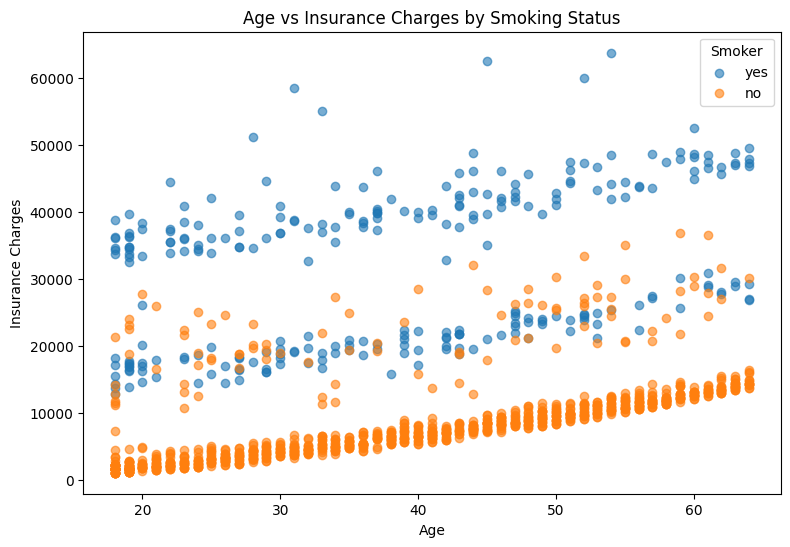

In [35]:
plt.figure(figsize=(9, 6))

for status in df_clean["smoker"].unique():
    subset = df_clean[df_clean["smoker"] == status]

    plt.scatter(
        subset["age"],
        subset["charges"],
        alpha=0.6,
        label=status
    )

plt.title("Age vs Insurance Charges by Smoking Status")
plt.xlabel("Age")
plt.ylabel("Insurance Charges")
plt.legend(title="Smoker")

plt.show()

Interpretation: When smoking status is considered, the relationship between age and insurance charges becomes clearer. Insurance charges generally increase with age for both smokers and non-smokers. However, smokers tend to have substantially higher insurance charges than non-smokers across different age groups. Many smokers are concentrated in the higher-cost range, particularly above $30,000, while most non-smokers are concentrated at considerably lower charge levels.

This suggests that both age and smoking status are important factors associated with insurance charges, with smoking status appearing to explain a substantial part of the variation observed in the original age-versus-charges scatter plot. However, other characteristics, such as BMI, may also help explain the remaining differences.

In [36]:
df_clean["age"].corr(df_clean["charges"])

np.float64(0.2983082125097864)

Correlation Analysis: The correlation coefficient between age and insurance charges is approximately 0.30, indicating a weak positive linear relationship. This means that insurance charges tend to increase as age increases, although age alone does not strongly explain the variation in charges. Other factors, such as smoking status and BMI, are likely to contribute to differences in insurance costs.

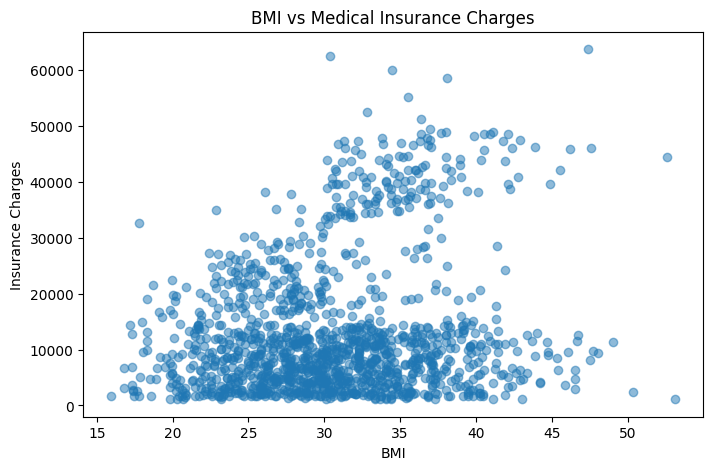

In [37]:
plt.figure(figsize=(8, 5))

plt.scatter(df_clean["bmi"], df_clean["charges"], alpha=0.5)

plt.title("BMI vs Medical Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")

plt.show()

In [38]:
df_clean[["bmi", "charges"]].corr()

,bmi,charges
bmi,1.000000,0.198401
charges,0.198401,1.000000


Interpretation: The scatter plot shows a weak positive relationship between BMI and medical insurance charges. The correlation coefficient is approximately 0.20, indicating that insurance charges tend to increase slightly as BMI increases. However, the points are widely dispersed, showing that BMI alone does not strongly explain the variation in insurance charges.

The plot also shows a group of individuals with substantially higher charges, particularly around BMI values of approximately 30 and above. This suggests that other factors may interact with BMI and contribute to higher insurance costs. Based on the earlier analysis, smoking status is one factor worth investigating alongside BMI.

In [39]:
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

df_clean["bmi_category"] = df_clean["bmi"].apply(bmi_category)

In [40]:
df_clean["bmi_category"].value_counts()

bmi_category
Obese          706
Overweight     386
Normal         225
Underweight     20
Name: count, dtype: int64

In [41]:
bmi_charges = df_clean.groupby("bmi_category")["charges"].mean()

bmi_charges

bmi_category
Normal         10409.337709
Obese          15572.041945
Overweight     10987.509891
Underweight     8852.200585
Name: charges, dtype: float64

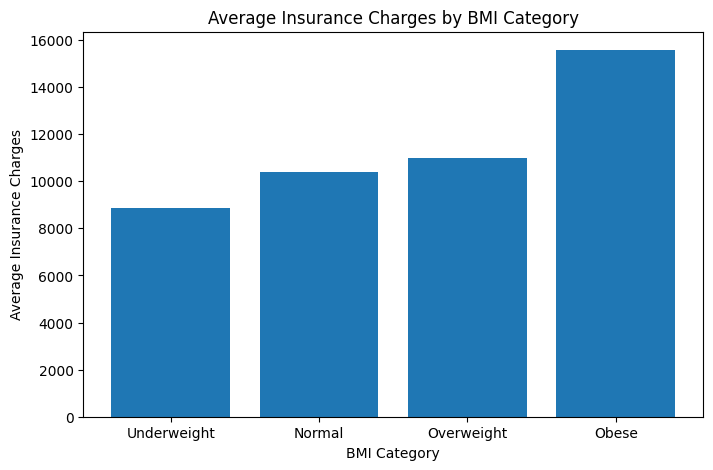

In [42]:
bmi_order = ["Underweight", "Normal", "Overweight", "Obese"]

bmi_charges = (
    df_clean.groupby("bmi_category")["charges"]
    .mean()
    .reindex(bmi_order)
)

plt.figure(figsize=(8, 5))

plt.bar(bmi_charges.index, bmi_charges.values)

plt.title("Average Insurance Charges by BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("Average Insurance Charges")

plt.show()

In [43]:
bmi_charges.round(2)

bmi_category
Underweight     8852.20
Normal         10409.34
Overweight     10987.51
Obese          15572.04
Name: charges, dtype: float64

Interpretation: The analysis shows that average medical insurance charges generally increase across the BMI categories. The underweight group has the lowest average charges, at approximately $8,852.20, while the obese group has the highest average charges, at approximately $15,557.04. The normal and overweight groups have average charges of approximately $10,409.34 and $10,987.51, respectively.

The largest difference is observed for the obese category, whose average insurance charges are noticeably higher than those of the other BMI groups. This suggests that BMI category is associated with medical insurance costs in this dataset. However, BMI should not be considered in isolation because other factors, particularly smoking status and age, may contribute to these differences.

In [44]:
sex_charges = df_clean.groupby("sex")["charges"].mean()

sex_charges

sex
female    12569.578844
male      13974.998864
Name: charges, dtype: float64

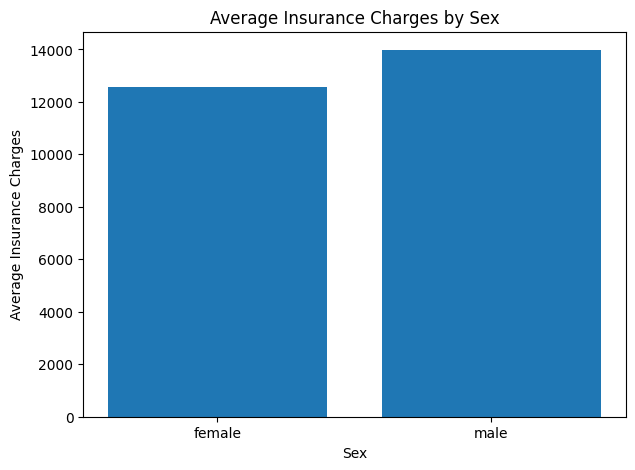

In [45]:
plt.figure(figsize=(7, 5))

plt.bar(sex_charges.index, sex_charges.values)

plt.title("Average Insurance Charges by Sex")
plt.xlabel("Sex")
plt.ylabel("Average Insurance Charges")

plt.show()

Interpretation: The analysis shows that males have slightly higher average medical insurance charges than females. The average charge for males is approximately $13,975.00, compared with $12,569.58 for females, representing a difference of approximately $1,405.42.

Although males have higher average charges, the difference is relatively small compared with the much larger difference observed between smokers and non-smokers. This suggests that sex alone may not be a major factor in explaining variations in insurance charges. Other characteristics, particularly smoking status, age, and BMI, may contribute to the observed difference.

In [46]:
children_charges = df_clean.groupby("children")["charges"].mean()

children_charges

children
0    12384.695344
1    12731.171832
2    15073.563734
3    15355.318367
4    13850.656311
5     8786.035247
Name: charges, dtype: float64

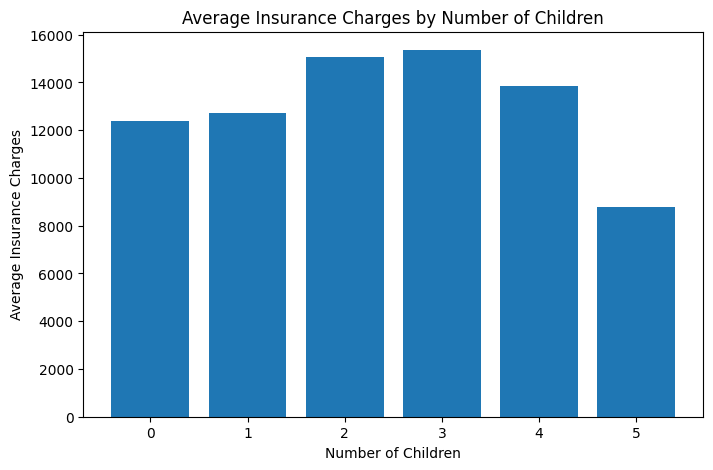

In [47]:
plt.figure(figsize=(8, 5))

plt.bar(children_charges.index.astype(str), children_charges.values)

plt.title("Average Insurance Charges by Number of Children")
plt.xlabel("Number of Children")
plt.ylabel("Average Insurance Charges")

plt.show()

In [48]:
df_clean["children"].value_counts().sort_index()

children
0    573
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

Interpretation: Average insurance charges increase from approximately $12,384.70 for customers with no children to $15,355.32 for customers with three children, after which the average decreases. Customers with five children have the lowest average charge of approximately $8,786.04.

However, the number of observations differs considerably across the groups. There are 573 customers with no children, compared with only 25 customers with four children and 18 customers with five children. Therefore, the lower average observed for customers with five children should be interpreted cautiously because it is based on a relatively small group.

Overall, there is no consistent pattern showing that insurance charges increase as the number of children increases. Other characteristics such as age, BMI, and smoking status may have stronger relationships with insurance charges.

In [49]:
region_charges = (
    df_clean.groupby("region")["charges"]
    .mean()
    .sort_values(ascending=False)
)

region_charges

region
southeast    14735.411438
northeast    13406.384516
northwest    12450.840844
southwest    12346.937377
Name: charges, dtype: float64

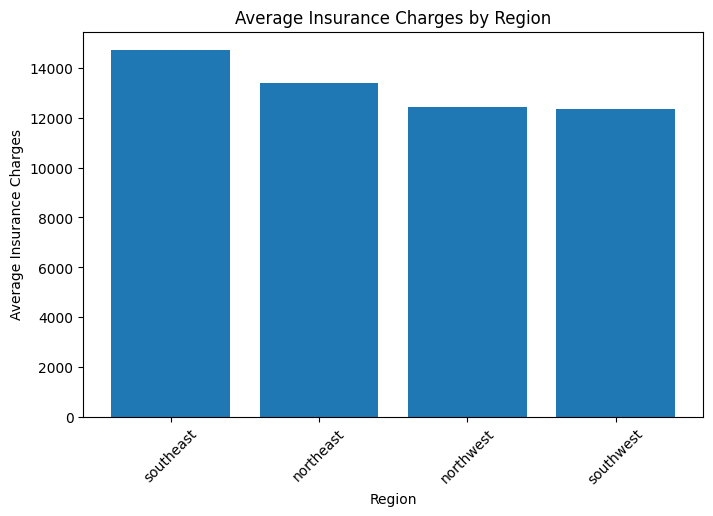

In [50]:
plt.figure(figsize=(8, 5))

plt.bar(region_charges.index, region_charges.values)

plt.title("Average Insurance Charges by Region")
plt.xlabel("Region")
plt.ylabel("Average Insurance Charges")
plt.xticks(rotation=45)

plt.show()

Interpretation: The analysis shows some variation in average medical insurance charges across the four regions. The Southeast has the highest average charge at approximately $14,735.41, followed by the Northeast at $13,406.38. The Northwest and Southwest have lower average charges of approximately $12,450.84 and $12,346.94, respectively.

Although the Southeast records the highest average insurance charge, the differences between regions are considerably smaller than the difference previously observed between smokers and non-smokers. This suggests that region may have some relationship with insurance charges, but other characteristics such as smoking status, age, and BMI may be more strongly associated with the variation in medical insurance costs.

In [51]:
bins = [17, 25, 35, 45, 55, 65]
labels = ["18-25", "26-35", "36-45", "46-55", "56-64"]

df_clean["age_group"] = pd.cut(
    df_clean["age"],
    bins=bins,
    labels=labels
)

In [52]:
df_clean["age_group"].value_counts().sort_index()

age_group
18-25    305
26-35    268
36-45    264
46-55    284
56-64    216
Name: count, dtype: int64

In [53]:
age_charges = (
    df_clean.groupby("age_group", observed=False)["charges"]
    .mean()
)

age_charges

age_group
18-25     9111.433685
26-35    10495.163047
36-45    13493.485247
46-55    15986.900310
56-64    18795.993816
Name: charges, dtype: float64

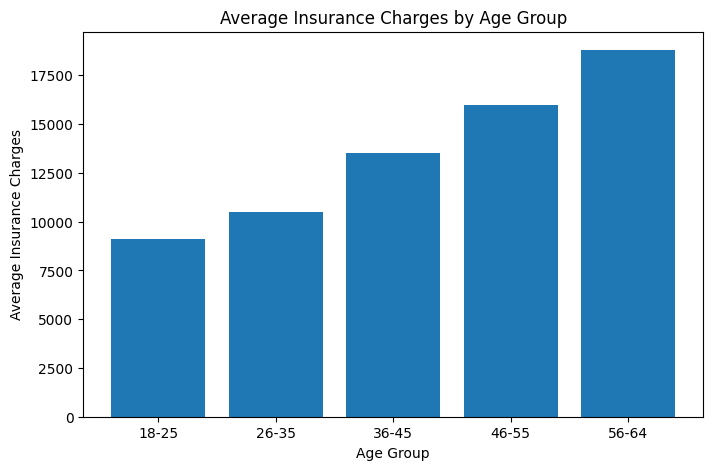

In [54]:
plt.figure(figsize=(8, 5))

plt.bar(age_charges.index.astype(str), age_charges.values)

plt.title("Average Insurance Charges by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Insurance Charges")

plt.show()

Interpretation: The analysis shows a clear increase in average medical insurance charges across the age groups. Individuals aged 18–25 have the lowest average charge of approximately $9,111.43, while those aged 56–64 have the highest average charge of approximately $18,796.00.

Average charges increase progressively from $10,495.16 for ages 26–35, to $13,493.49 for ages 36–45, and $15,986.90 for ages 46–55. This indicates that older age groups are associated with higher average medical insurance charges in this dataset.

The group sizes are also reasonably substantial across all five categories, ranging from 216 to 305 observations, so the pattern is not being driven by an extremely small age group. However, this analysis shows an association rather than proving that age alone causes higher insurance charges, since factors such as smoking status and BMI may also contribute.

In [55]:
smoker_bmi = (
    df_clean.groupby(["bmi_category", "smoker"], observed=False)["charges"]
    .mean()
    .unstack()
)

smoker_bmi

smoker,no,yes
bmi_category,,
Normal,7685.656014,19942.223641
Obese,8855.531349,41557.989840
Overweight,8257.961955,22495.874163
Underweight,5532.992453,18809.824980


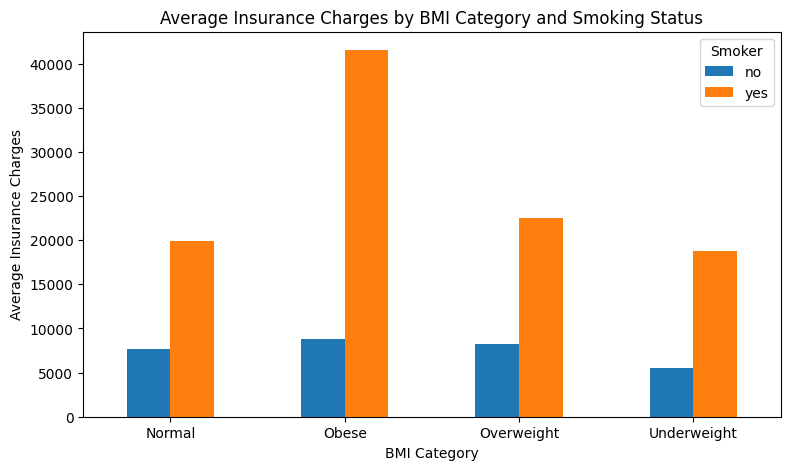

In [56]:
smoker_bmi.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Average Insurance Charges by BMI Category and Smoking Status")
plt.xlabel("BMI Category")
plt.ylabel("Average Insurance Charges")
plt.xticks(rotation=0)
plt.legend(title="Smoker")

plt.show()

Interpretation: The combined analysis of BMI category and smoking status reveals a substantial difference in medical insurance charges. Across every BMI category, smokers have considerably higher average insurance charges than non-smokers.

The most notable result occurs among individuals in the obese BMI category. Obese smokers have an average insurance charge of approximately $41,557.99, compared with only $8,855.53 for obese non-smokers. Smokers in the normal, overweight, and underweight categories also have higher average charges than their non-smoking counterparts.

This analysis suggests that the relationship between BMI and insurance charges differs substantially according to smoking status. In particular, the combination of smoking and obesity is associated with especially high insurance charges in this dataset. This also helps explain why BMI alone showed only a weak correlation with charges earlier: examining BMI together with smoking status reveals a pattern that the overall BMI correlation does not capture.

These findings describe associations in the dataset and should not be interpreted as establishing causation.

In [57]:
numeric_columns = ["age", "bmi", "children", "charges"]

correlation = df_clean[numeric_columns].corr()

correlation

,age,bmi,children,charges
age,1.000000,0.109344,0.041536,0.298308
bmi,0.109344,1.000000,0.012755,0.198401
children,0.041536,0.012755,1.000000,0.067389
charges,0.298308,0.198401,0.067389,1.000000


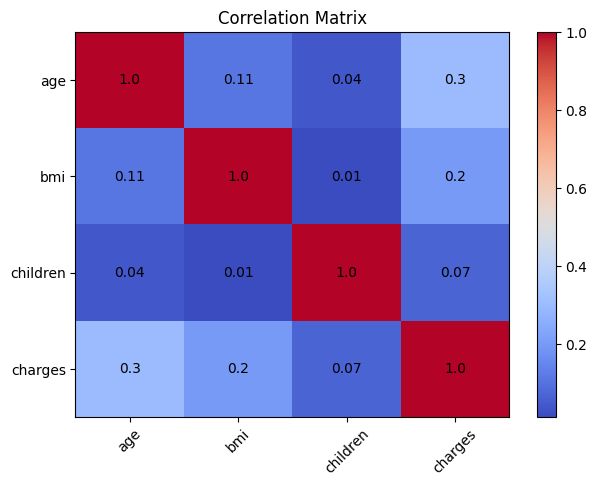

In [58]:
plt.figure(figsize=(7, 5))

plt.imshow(correlation, cmap="coolwarm", aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(
            j,
            i,
            round(correlation.iloc[i, j], 2),
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix")

plt.show()

Interpretation: The correlation matrix shows that among the numerical variables examined, age has the strongest positive linear relationship with insurance charges, with a correlation coefficient of approximately 0.30. BMI has a weaker positive correlation with charges of approximately 0.20, while the number of children has a very weak positive correlation of approximately 0.07.

These results suggest that none of the numerical variables individually has a strong linear relationship with insurance charges. However, the earlier exploratory analysis showed that categorical factors, particularly smoking status, are strongly associated with differences in insurance charges. The combined BMI and smoking analysis also showed that relationships between variables may be more complex than simple pairwise correlations reveal.

Therefore, the correlation matrix should be considered alongside the other EDA results rather than being used alone to determine which variables are important for predicting insurance charges.

## Key Findings

1. The distribution of medical insurance charges is right-skewed, with most individuals having relatively lower charges and a smaller number having substantially higher charges.
2. Smoking status shows one of the clearest differences in insurance charges. Smokers have average charges of approximately $32,050, compared with approximately $8,441 for non-smokers.
3. Age is positively associated with insurance charges. The correlation between age and charges is approximately 0.30, and average charges increase consistently across the age groups, from approximately $9,111 for ages 18–25 to $18,796 for ages 56–64.
4. BMI has a weak positive linear correlation with insurance charges of approximately 0.20. However, categorising BMI revealed that the obese group has higher average charges than the other BMI categories.
5. The combined analysis of BMI and smoking status revealed an important pattern. Obese smokers have average charges of approximately $41,558, compared with approximately $8,856 for obese non-smokers. This suggests that considering BMI together with smoking status provides more information than examining BMI alone.
6. Males have slightly higher average charges ($13,975) than females ($12,570), although this difference is considerably smaller than the difference associated with smoking status.
7. The number of children does not show a consistent relationship with insurance charges. Its correlation with charges is only approximately 0.07. Groups with four and five children also contain relatively few observations, so their averages should be interpreted cautiously.
8. The Southeast has the highest regional average charge at approximately $14,735, while the Southwest has the lowest at approximately $12,347. The regional differences are smaller than the differences observed for smoking status.

Overall Conclusion: The EDA indicates that medical insurance charges are associated with several customer characteristics, but the relationships differ substantially across variables. Smoking status shows a particularly large difference in average charges, while age also displays a consistent positive pattern. BMI becomes especially informative when considered together with smoking status. These findings provide a basis for selecting and preparing variables for predictive modelling.

In [59]:
df_clean.to_csv("medical_insurance_cleaned.csv", index=False)

In [60]:
import os

os.path.exists("medical_insurance_cleaned.csv")

True

In [61]:
df_clean.head()

,age,sex,bmi,children,smoker,region,charges,bmi_category,age_group
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight,18-25
1,18,male,33.770,1,no,southeast,1725.55230,Obese,18-25
2,28,male,33.000,3,no,southeast,4449.46200,Obese,26-35
3,33,male,22.705,0,no,northwest,21984.47061,Normal,26-35
4,32,male,28.880,0,no,northwest,3866.85520,Overweight,26-35


In [62]:
df_clean.columns.tolist()

['age',
 'sex',
 'bmi',
 'children',
 'smoker',
 'region',
 'charges',
 'bmi_category',
 'age_group']

In [63]:
check_df = pd.read_csv("medical_insurance_cleaned.csv")

check_df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_category,age_group
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight,18-25
1,18,male,33.770,1,no,southeast,1725.55230,Obese,18-25
2,28,male,33.000,3,no,southeast,4449.46200,Obese,26-35
3,33,male,22.705,0,no,northwest,21984.47061,Normal,26-35
4,32,male,28.880,0,no,northwest,3866.85520,Overweight,26-35


In [64]:
check_df.shape

(1337, 9)

In [65]:
df_clean.shape

(1337, 9)

In [66]:
import os

print(os.getcwd())

C:\Users\USER\Medical-Insurance-Cost-Prediction


In [67]:
print(os.path.abspath("medical_insurance_cleaned.csv"))

C:\Users\USER\Medical-Insurance-Cost-Prediction\medical_insurance_cleaned.csv


In [68]:
df_clean.to_csv("medical_insurance_cleaned.csv", index=False)

print("Shape:", df_clean.shape)

print("Columns:", df_clean.columns.tolist())

print("Saved to:", os.path.abspath("medical_insurance_cleaned.csv"))

Shape: (1337, 9)
Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'bmi_category', 'age_group']
Saved to: C:\Users\USER\Medical-Insurance-Cost-Prediction\medical_insurance_cleaned.csv


## Exploratory Data Analysis (EDA)

The purpose of this section is to explore the dataset and understand the relationships between patient characteristics and medical insurance charges.

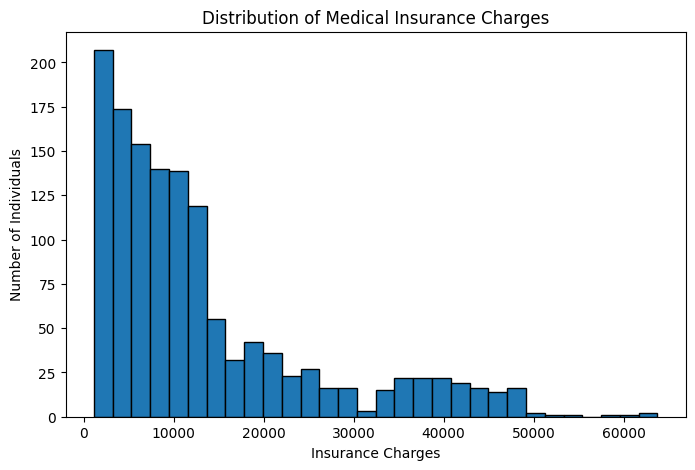

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df_clean['charges'], bins=30, edgecolor='black')

plt.title('Distribution of Medical Insurance Charges')
plt.xlabel('Insurance Charges')
plt.ylabel('Number of Individuals')

plt.show()

<Figure size 700x500 with 0 Axes>

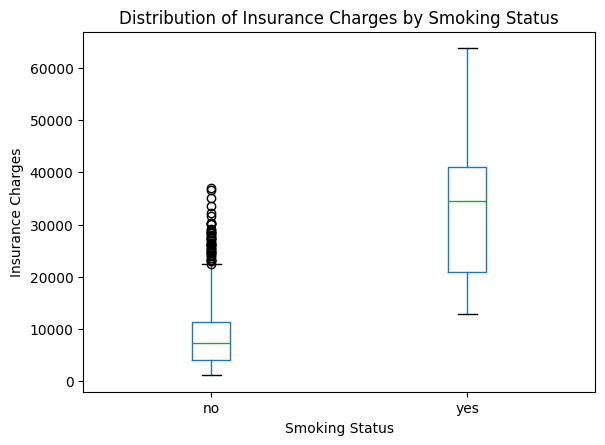

In [70]:
plt.figure(figsize=(7, 5))

df_clean.boxplot(
    column="charges",
    by="smoker",
    grid=False
)

plt.title("Distribution of Insurance Charges by Smoking Status")
plt.suptitle("")
plt.xlabel("Smoking Status")
plt.ylabel("Insurance Charges")

plt.show()

Interpretation:
The boxplot shows a substantial difference in medical insurance charges between smokers and non-smokers. Smokers have a considerably higher median charge and a wider spread of insurance costs than non-smokers. Although several high-cost observations are present among non-smokers, the overall distribution of charges for smokers is much higher. Together with the earlier comparison of mean charges, this suggests that smoking status has a strong association with medical insurance charges in this dataset. However, this analysis demonstrates association rather than causation.

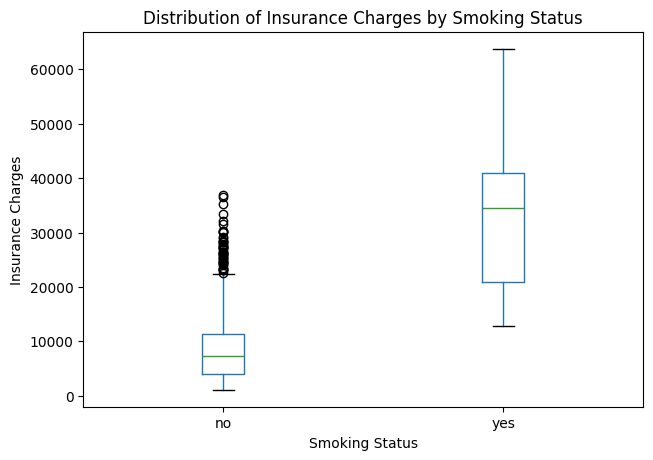

In [71]:
ax = df_clean.boxplot(
    column="charges",
    by="smoker",
    grid=False,
    figsize=(7, 5)
)

plt.title("Distribution of Insurance Charges by Smoking Status")
plt.suptitle("")
plt.xlabel("Smoking Status")
plt.ylabel("Insurance Charges")

plt.show()

Interpretation:
The boxplot reveals a substantial difference in insurance charges between smokers and non-smokers. Smokers have a considerably higher median insurance charge and a wider distribution of costs compared with non-smokers. Although several high-cost observations appear as outliers among non-smokers, the overall distribution for smokers remains much higher. This suggests that smoking status is strongly associated with medical insurance charges in this dataset. However, the relationship represents an association and does not by itself establish causation.

## Key Findings from Exploratory Data Analysis

1. Insurance charges are right-skewed, with a smaller number of individuals experiencing very high medical costs.
2. Insurance charges generally increase with age.
3. Smoking status shows a strong association with insurance charges, with smokers having substantially higher charges than non-smokers.
4. BMI alone has a relatively weak positive correlation with insurance charges, but its relationship becomes more pronounced when smoking status is considered.
5. Obese smokers show particularly high average insurance charges, indicating an important interaction between BMI and smoking status.
6. Sex and region show comparatively smaller differences in average insurance charges.
7. The number of children does not show a clear consistent relationship with insurance charges.
8. Overall, age, smoking status, BMI, and the interaction between BMI and smoking status appear particularly relevant for predicting insurance charges.

# Machine Learning: Predicting Medical Insurance Charges

The objective of this section is to develop regression models that can predict medical insurance charges based on individual characteristics such as age, BMI, smoking status, sex, number of children, and region.

The target variable is **charges**, while the remaining relevant variables will be used as predictor features.

In [72]:
df_clean.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'bmi_category', 'age_group'],
      dtype='str')

In [73]:
# Select predictor variables
X = df_clean[
    ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
]

# Select target variable
y = df_clean['charges']

In [74]:
X.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


In [75]:
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [76]:
X.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


In [77]:
# One-hot encode categorical variables
X_encoded = pd.get_dummies(
    X,
    columns=['sex', 'smoker', 'region'],
    drop_first=True,
    dtype=int
)

X_encoded.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,0,1,0,0,1
1,18,33.770,1,1,0,0,1,0
2,28,33.000,3,1,0,0,1,0
3,33,22.705,0,1,0,1,0,0
4,32,28.880,0,1,0,1,0,0


## Train-Test Split

The dataset is divided into training and testing sets. 
80% of the observations are used to train the machine learning model, while the remaining 20% are reserved for evaluating its predictive performance on unseen data.

In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

In [79]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1069, 8)
X_test shape: (268, 8)
y_train shape: (1069,)
y_test shape: (268,)


## Linear Regression Model

Linear Regression is used as the baseline regression model for predicting medical insurance charges. The model is trained using the training dataset and then used to predict insurance charges for the unseen test dataset.

In [80]:
from sklearn.linear_model import LinearRegression

# Create the model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 248.21, 318.7 , 533.01,...,-391.76,-838.92,-659.14]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['age','bmi','children',...,'region_northwest','region_southeast', 'region_southwest']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.109e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [81]:
# Predict insurance charges using the test data
y_pred = linear_model.predict(X_test)

# Display the first 10 predictions
y_pred[:10]

array([ 8143.69388412,  5737.11568259, 14369.31487618, 31745.51363586,
        8962.38665706, 13149.72235307, 30446.76067941,  1453.28881259,
       10633.01840233, 11318.94379361])

In [82]:
comparison = pd.DataFrame({
    "Actual Charges": y_test.values,
    "Predicted Charges": y_pred
})

comparison.head(10)

,Actual Charges,Predicted Charges
0,8688.85885,8143.693884
1,5708.86700,5737.115683
2,11436.73815,14369.314876
3,38746.35510,31745.513636
4,4463.20510,8962.386657
5,9304.70190,13149.722353
6,38511.62830,30446.760679
7,2150.46900,1453.288813
8,7345.72660,10633.018402
9,10264.44210,11318.943794


In [83]:
comparison.head(10)

,Actual Charges,Predicted Charges
0,8688.85885,8143.693884
1,5708.86700,5737.115683
2,11436.73815,14369.314876
3,38746.35510,31745.513636
4,4463.20510,8962.386657
5,9304.70190,13149.722353
6,38511.62830,30446.760679
7,2150.46900,1453.288813
8,7345.72660,10633.018402
9,10264.44210,11318.943794


## Model Evaluation

The performance of the Linear Regression model is evaluated using three regression metrics:

- **Mean Absolute Error (MAE):** Measures the average absolute difference between the actual and predicted insurance charges.
- **Root Mean Squared Error (RMSE):** Measures prediction error while giving greater weight to larger errors.
- **R² Score:** Measures the proportion of variation in insurance charges explained by the model. Values closer to 1 indicate greater explanatory performance on the test data.

In [84]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 4177.05
Root Mean Squared Error (RMSE): 5956.34
R² Score: 0.8069


### Interpretation of Model Performance

The Linear Regression model achieved an R² score of **0.8069**, indicating that approximately **80.69% of the variation in insurance charges in the test dataset is explained by the predictor variables included in the model.

The Mean Absolute Error (MAE) was **4,177.05**, meaning that the model's predictions differ from the actual insurance charges by approximately 4,177 monetary units on average.

The Root Mean Squared Error (RMSE) was **5,956.34**. Since the RMSE is higher than the MAE, this indicates that some observations have relatively large prediction errors.

Overall, the Linear Regression model provides a useful baseline for predicting insurance charges, although there is still unexplained variation and room for improvement.

## Actual vs Predicted Insurance Charges

The scatter plot below compares the actual insurance charges with the values predicted by the Linear Regression model. Predictions closer to the diagonal reference line indicate greater predictive accuracy.

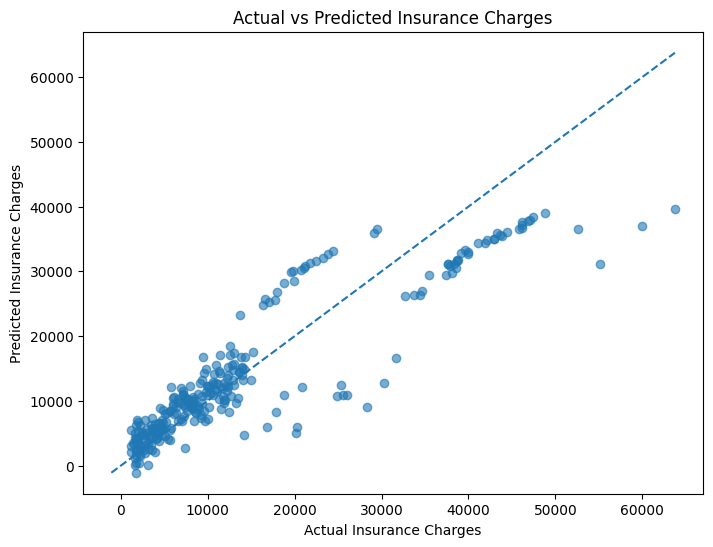

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Perfect prediction reference line
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Insurance Charges")
plt.ylabel("Predicted Insurance Charges")
plt.title("Actual vs Predicted Insurance Charges")

plt.show()

### Interpretation

The Actual vs Predicted plot shows that the Linear Regression model captures the general pattern of insurance charges reasonably well. Many observations, particularly those with lower charges, lie relatively close to the diagonal reference line.

However, noticeable deviations occur for some observations. In particular, several high-cost observations fall below the reference line, indicating that the model tends to underestimate some of the higher insurance charges.

This suggests that while the model provides useful predictive performance overall, the relationship between the predictors and insurance charges may not be completely linear.

## Residual Analysis

Residuals represent the difference between the actual insurance charges and the values predicted by the model. Examining the residuals helps assess the prediction errors and determine whether systematic patterns remain unexplained by the Linear Regression model.

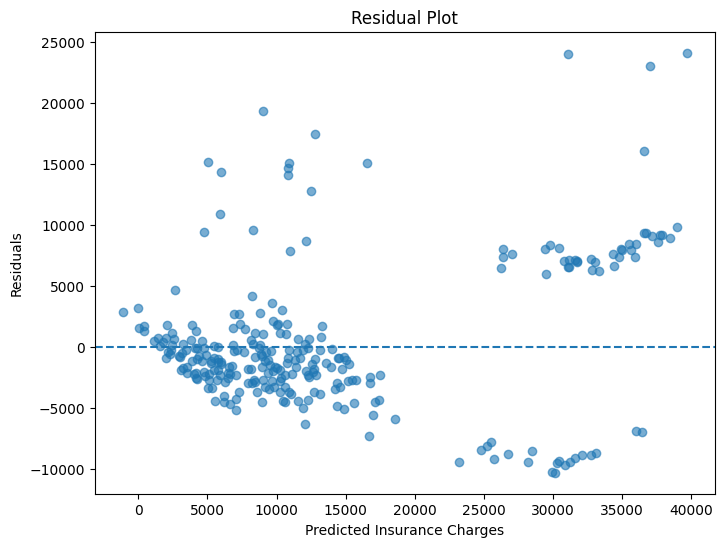

In [86]:
# Calculate residuals
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.6)

# Zero-error reference line
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Insurance Charges")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

### Residual Plot Interpretation

The residual plot shows that the prediction errors are not completely randomly distributed around the zero line. Several clusters and relatively large residuals are visible, particularly for higher predicted insurance charges.

Positive residuals indicate cases where the model underestimated the actual insurance charges, while negative residuals indicate cases where the model overestimated the charges.

The presence of visible patterns suggests that a simple Linear Regression model may not fully capture all relationships in the data. Although the model achieved an R² score of approximately 0.81, there is still room for improvement, particularly for observations with higher insurance charges.

## Feature Influence — Linear Regression Coefficients

To better understand the Linear Regression model, the coefficients of the predictor variables are examined. Each coefficient represents the estimated change in insurance charges associated with a one-unit change in the corresponding feature, while holding the other variables constant.

For categorical variables created through one-hot encoding, the coefficient represents the estimated difference relative to the omitted reference category.

In [87]:
# Extract Linear Regression coefficients

coefficients = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Coefficient": linear_model.coef_
})

# Sort from largest to smallest coefficient
coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient
4,smoker_yes,23077.764593
2,children,533.009989
1,bmi,318.701441
0,age,248.210720
3,sex_male,-101.542054
5,region_northwest,-391.761455
7,region_southwest,-659.139752
6,region_southeast,-838.919616


### Interpretation of Linear Regression Coefficients

The Linear Regression coefficients provide insight into how the predictor variables are associated with predicted insurance charges while holding the other variables constant.

Smoking status has the largest positive coefficient. Being a smoker is associated with approximately 23,078 higher predicted insurance charges compared with being a non-smoker, after accounting for the other variables in the model.

The number of children, BMI, and age also have positive coefficients. Each additional child is associated with an increase of approximately 533 in predicted charges, while a one-unit increase in BMI is associated with an increase of approximately 319. Each additional year of age is associated with an increase of approximately 248 in predicted insurance charges.

The coefficient for sex_male is approximately -102, indicating a relatively small estimated difference compared with females. The regional coefficients are also negative relative to the omitted reference category, northeast.

Overall, smoking status shows a particularly large estimated difference in predicted charges. However, the coefficients represent associations within this model and should not be interpreted as evidence of causation.

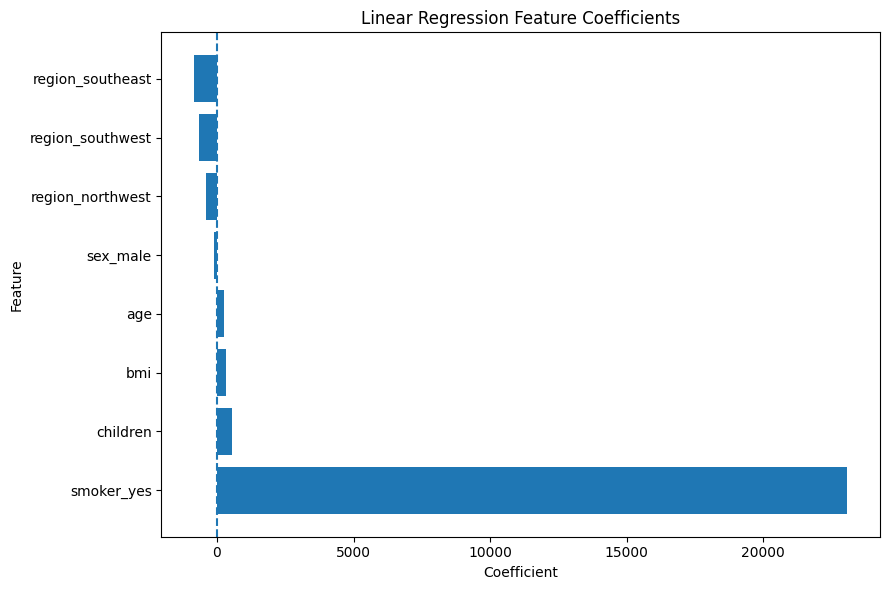

In [88]:
plt.figure(figsize=(9, 6))

plt.barh(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.axvline(x=0, linestyle="--")

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Linear Regression Feature Coefficients")

plt.tight_layout()
plt.show()


| Feature            | Coefficient | Interpretation                                                                                                 |
| ------------------ | ----------: | -------------------------------------------------------------------------------------------------------------- |
| `smoker_yes`       |   23,077.76 | Smokers are predicted to have substantially higher charges than non-smokers, holding other variables constant. |
| `children`         |      533.01 | Each additional child is associated with about 533 higher predicted charges.                                   |
| `bmi`              |      318.70 | A one-unit increase in BMI is associated with about 319 higher predicted charges.                              |
| `age`              |      248.21 | Each additional year of age is associated with about 248 higher predicted charges.                             |
| `sex_male`         |     -101.54 | Males are predicted to have about 102 lower charges than females, all else equal.                              |
| `region_northwest` |     -391.76 | Northwest is about 392 lower than the reference region.                                                        |
| `region_southwest` |     -659.14 | Southwest is about 659 lower than the reference region.                                                        |
| `region_southeast` |     -838.92 | Southeast is about 839 lower than the reference region.                                                        |


## Model 2 — Random Forest Regression

A Random Forest Regressor is used as a second predictive model to determine whether a nonlinear machine learning approach can improve the prediction of insurance charges.

Unlike Linear Regression, Random Forest can capture more complex and nonlinear relationships between the predictor variables and insurance charges. The model will be trained using the same training data and evaluated on the same test data to allow a fair comparison with the Linear Regression model.

In [90]:
from sklearn.ensemble import RandomForestRegressor

# Create the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### Random Forest Predictions

The trained Random Forest model is used to predict insurance charges for the test dataset. These predictions are then compared with the actual insurance charges to evaluate the model's predictive performance.

In [91]:
# Predict insurance charges using the Random Forest model
rf_pred = rf_model.predict(X_test)

# Display the first 10 predictions
rf_pred[:10]

array([ 9293.3126237,  8996.2384818, 11864.9644436, 42027.69325  ,
        6631.8989428,  9804.4462166, 38078.616941 ,  2245.829323 ,
       10142.9699376, 11015.024348 ])

In [92]:
rf_comparison = pd.DataFrame({
    "Actual Charges": y_test.values,
    "Predicted Charges": rf_pred
})

rf_comparison.head(10)

,Actual Charges,Predicted Charges
0,8688.85885,9293.312624
1,5708.86700,8996.238482
2,11436.73815,11864.964444
3,38746.35510,42027.693250
4,4463.20510,6631.898943
5,9304.70190,9804.446217
6,38511.62830,38078.616941
7,2150.46900,2245.829323
8,7345.72660,10142.969938
9,10264.44210,11015.024348


### Random Forest Model Evaluation

The Random Forest model is evaluated using the same regression metrics used for the Linear Regression model:

- **Mean Absolute Error (MAE):** Measures the average absolute difference between actual and predicted insurance charges.
- **Root Mean Squared Error (RMSE):** Measures prediction error while giving greater weight to larger errors.
- **R² Score:** Measures the proportion of variation in insurance charges explained by the model.

In [93]:
# Calculate Random Forest evaluation metrics

rf_mae = mean_absolute_error(y_test, rf_pred)

rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest MAE: {rf_mae:.2f}")
print(f"Random Forest RMSE: {rf_rmse:.2f}")
print(f"Random Forest R² Score: {rf_r2:.4f}")

Random Forest MAE: 2631.95
Random Forest RMSE: 4696.32
Random Forest R² Score: 0.8800


## Model Comparison

To compare the predictive performance of the two regression models, the Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score are examined.

Lower MAE and RMSE values indicate smaller prediction errors, while a higher R² score indicates that the model explains a greater proportion of the variation in insurance charges.

In [94]:
# Create model comparison table

model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "RMSE": [rmse, rf_rmse],
    "R² Score": [r2, rf_r2]
})

model_comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,4177.045561,5956.342894,0.806929
1,Random Forest,2631.953730,4696.318881,0.879975


### Interpretation of Model Comparison

The Random Forest model achieved lower MAE and RMSE values than the Linear Regression model on the test dataset. Its MAE decreased from approximately 4,177.05 to 2,631.95, while RMSE decreased from approximately 5,956.34 to 4,696.32.

The Random Forest model also achieved a higher R² score of 0.8800 compared with 0.8069 for Linear Regression. This indicates that, for this train-test split, the Random Forest model explained approximately 88% of the variation in insurance charges.

These results suggest that the nonlinear Random Forest model captures patterns in the dataset that are not fully represented by the Linear Regression model. However, further validation, such as cross-validation, can be used to assess whether this improvement remains consistent across different subsets of the data.

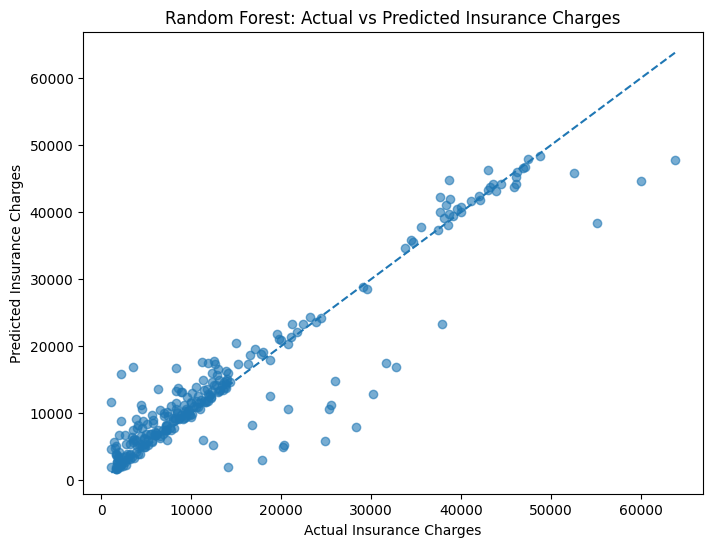

In [95]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, rf_pred, alpha=0.6)

# Perfect prediction reference line
min_value = min(y_test.min(), rf_pred.min())
max_value = max(y_test.max(), rf_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Insurance Charges")
plt.ylabel("Predicted Insurance Charges")
plt.title("Random Forest: Actual vs Predicted Insurance Charges")

plt.show()

## Interpretation of Random Forest Predictions

The Random Forest prediction plot shows a strong positive relationship between the actual and predicted insurance charges. Most observations lie close to the dashed reference line, indicating that the model predicts many insurance charges with relatively small errors.

Compared with the Linear Regression model, the predictions appear more tightly clustered around the ideal line, particularly for low- and medium-cost insurance charges. Although some high-cost observations remain underpredicted, the overall spread of prediction errors is smaller, supporting the improved MAE, RMSE, and R² values obtained during model evaluation.

This suggests that the Random Forest model captures nonlinear relationships in the insurance dataset more effectively than the Linear Regression model.

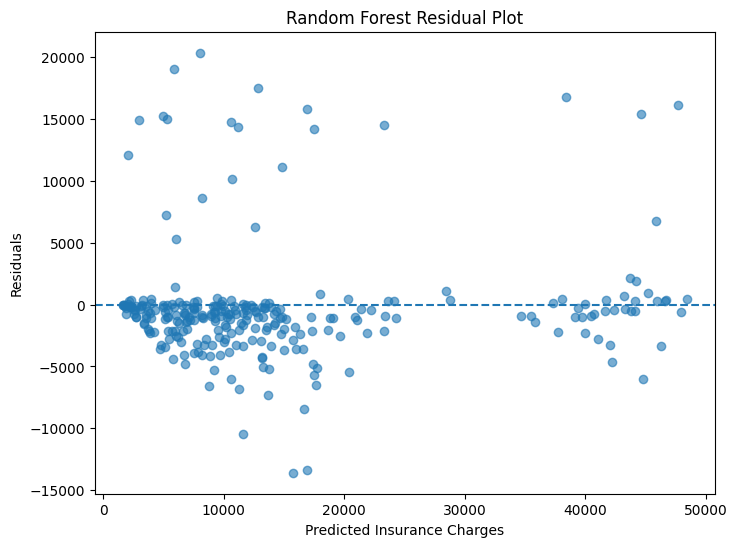

In [96]:
# Random Forest residual plot

rf_residuals = y_test - rf_pred

plt.figure(figsize=(8,6))

plt.scatter(rf_pred, rf_residuals, alpha=0.6)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Insurance Charges")
plt.ylabel("Residuals")
plt.title("Random Forest Residual Plot")

plt.show()

### Interpretation of the Random Forest Residual Plot

The residual plot shows that many prediction errors are concentrated around the zero line, indicating that the Random Forest model produces relatively accurate predictions for a substantial proportion of the observations.

However, several larger positive and negative residuals are also present. Positive residuals indicate cases where the model underestimated the actual insurance charges, while negative residuals indicate cases where the model overestimated the charges.

Compared with the Linear Regression residual plot, the Random Forest model shows a greater concentration of residuals around zero, which is consistent with its lower MAE and RMSE and higher R² score. Nevertheless, the presence of some large residuals indicates that certain insurance charges remain difficult for the model to predict accurately.

Overall, the residual analysis supports the improved predictive performance of the Random Forest model while also showing that prediction errors have not been completely eliminated.

In [97]:
# Random Forest Feature Importance

importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
4,smoker_yes,0.600777
1,bmi,0.216251
0,age,0.135697
2,children,0.022922
3,sex_male,0.007060
5,region_northwest,0.006676
6,region_southeast,0.006059
7,region_southwest,0.004558


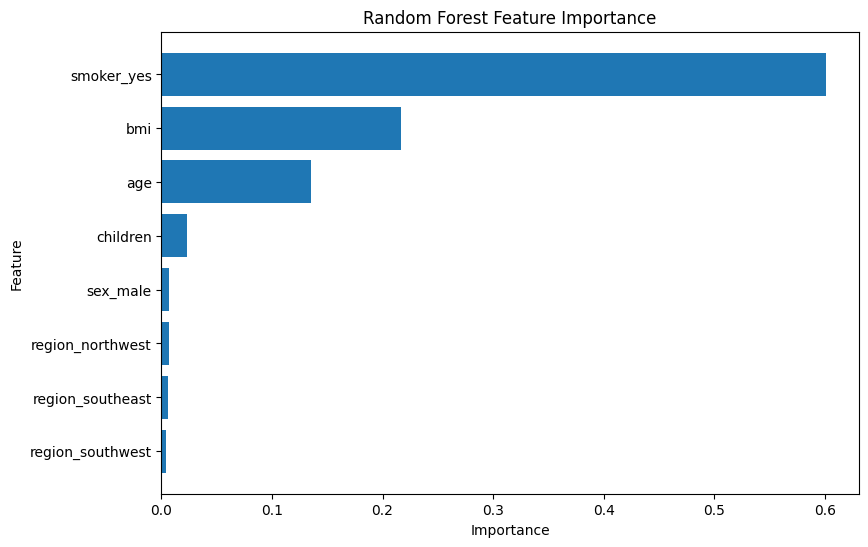

In [98]:
plt.figure(figsize=(9,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.show()

### Interpretation of Random Forest Feature Importance

The Random Forest feature importance analysis shows that smoking status is the most influential predictor in the model, with an importance value of approximately 0.601 (60.1%). This is substantially higher than the importance of the other predictor variables.

BMI is the second most important feature, accounting for approximately 21.6% of the model's total feature importance, followed by age at approximately 13.6%. Together, smoking status, BMI, and age account for approximately 95% of the total feature importance.

The number of children contributes relatively little to the model, while sex and the encoded regional variables have the lowest feature importance values.

These results indicate that the Random Forest model relies primarily on smoking status, BMI, and age when predicting insurance charges. However, feature importance represents predictive contribution within the model and should not be interpreted as evidence of a causal relationship between these variables and insurance charges.

In [99]:
from sklearn.model_selection import cross_val_score

# Linear Regression Cross Validation
lr_cv = cross_val_score(
    linear_model,
    X_encoded,
    y,
    cv=5,
    scoring="r2"
)

# Random Forest Cross Validation
rf_cv = cross_val_score(
    rf_model,
    X_encoded,
    y,
    cv=5,
    scoring="r2"
)

print("Linear Regression CV R²:", lr_cv)
print("Average:", lr_cv.mean())

print()

print("Random Forest CV R²:", rf_cv)
print("Average:", rf_cv.mean())

Linear Regression CV R²: [0.76148609 0.70651382 0.77741544 0.73269494 0.7555821 ]
Average: 0.7467384760760104

Random Forest CV R²: [0.85389188 0.77901285 0.86917054 0.82767286 0.85105358]
Average: 0.8361603445279624


In [100]:
# Cross-validation summary

print("Linear Regression")
print(f"Mean CV R²: {lr_cv.mean():.4f}")
print(f"Standard Deviation: {lr_cv.std():.4f}")

print()

print("Random Forest")
print(f"Mean CV R²: {rf_cv.mean():.4f}")
print(f"Standard Deviation: {rf_cv.std():.4f}")

Linear Regression
Mean CV R²: 0.7467
Standard Deviation: 0.0247

Random Forest
Mean CV R²: 0.8362
Standard Deviation: 0.0315


### Interpretation of Cross-Validation Results

Five-fold cross-validation was used to evaluate the consistency and generalisation performance of the Linear Regression and Random Forest models.

The Linear Regression model achieved a mean cross-validation R² score of **0.7467** with a standard deviation of **0.0247**. This indicates that the model explained approximately **74.7% of the variation in insurance charges**, on average, across the five validation folds.

The Random Forest model achieved a higher mean cross-validation R² score of **0.8362** with a standard deviation of **0.0315**, indicating that it explained approximately **83.6% of the variation in insurance charges**, on average, across the validation folds.

Random Forest achieved a higher R² score than Linear Regression in all five folds. Although its cross-validation scores showed slightly greater variability, its overall predictive performance remained consistently higher.

These results support the Random Forest model as the stronger predictive model for insurance charges in this dataset.

# Model Comparison

The Linear Regression and Random Forest Regression models are compared using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), R² Score, and 5-fold cross-validation.

For MAE and RMSE, lower values indicate smaller prediction errors. For R², values closer to 1 indicate that the model explains a greater proportion of the variation in insurance charges.

In [101]:
# Create model comparison table

model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "RMSE": [rmse, rf_rmse],
    "Test R²": [r2, rf_r2],
    "CV Mean R²": [lr_cv.mean(), rf_cv.mean()]
})

model_comparison.round(4)

,Model,MAE,RMSE,Test R²,CV Mean R²
0,Linear Regression,4177.0456,5956.3429,0.8069,0.7467
1,Random Forest,2631.9537,4696.3189,0.8800,0.8362


In [102]:
# Final model comparison

final_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "Test MAE": [mae, rf_mae],
    "Test RMSE": [rmse, rf_rmse],
    "Test R²": [r2, rf_r2],
    "Mean CV R²": [lr_cv.mean(), rf_cv.mean()],
    "CV R² Std": [lr_cv.std(), rf_cv.std()]
})

final_comparison.round(4)

,Model,Test MAE,Test RMSE,Test R²,Mean CV R²,CV R² Std
0,Linear Regression,4177.0456,5956.3429,0.8069,0.7467,0.0247
1,Random Forest,2631.9537,4696.3189,0.8800,0.8362,0.0315


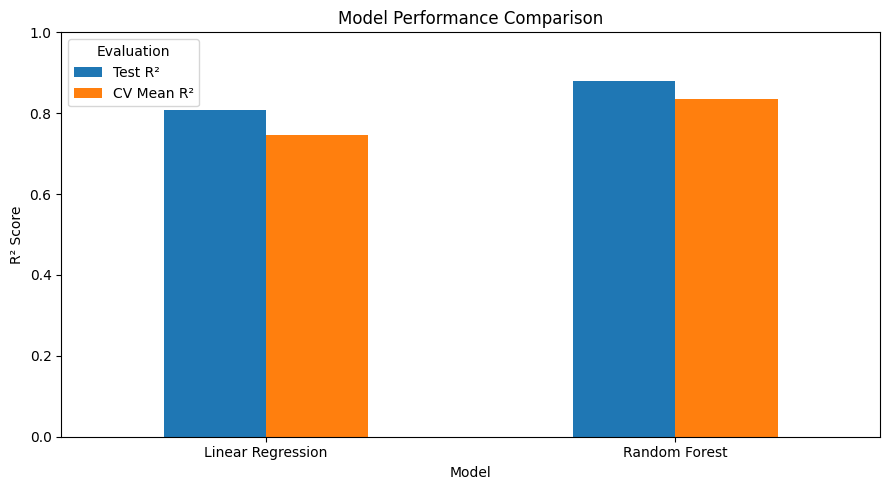

In [103]:
# Compare R² scores

r2_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "Test R²": [r2, rf_r2],
    "CV Mean R²": [lr_cv.mean(), rf_cv.mean()]
})

ax = r2_comparison.set_index("Model").plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Model Performance Comparison")
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Evaluation")
plt.tight_layout()

plt.show()

## Model Comparison Interpretation

The Random Forest Regression model demonstrated stronger predictive performance than the Linear Regression model on the evaluation metrics used in this project.

The Linear Regression model achieved a test R² of approximately **0.807**, compared with approximately **0.880** for Random Forest. This means that, on the test set, Random Forest explained a larger proportion of the observed variation in insurance charges.

Random Forest also produced lower prediction errors. Its MAE was approximately **2,631.95**, compared with **4,177.05** for Linear Regression, while its RMSE was approximately **4,696.32**, compared with **5,956.34** for Linear Regression.

The cross-validation results showed the same general pattern. Random Forest achieved an average 5-fold cross-validation R² of approximately **0.836**, while Linear Regression achieved approximately **0.747**.

These results indicate that the nonlinear Random Forest model captured patterns in this dataset that were not fully represented by the Linear Regression model.

However, Linear Regression remains valuable because its coefficients provide a more direct interpretation of the estimated relationships between individual predictors and insurance charges.

# Final Model Comparison and Selection

Two regression algorithms were evaluated for predicting insurance charges: Linear Regression and Random Forest Regression.

The Linear Regression model achieved a test R² score of approximately **0.807**, with an MAE of **4,177.05** and an RMSE of **5,956.34**. Its mean 5-fold cross-validation R² score was approximately **0.747**.

The Random Forest model achieved a higher test R² score of approximately **0.880**, with a lower MAE of **2,631.95** and RMSE of **4,696.32**. Its mean 5-fold cross-validation R² score was approximately **0.836**.

Across the evaluation metrics used in this project, Random Forest produced stronger predictive results on this dataset. Its higher R² values indicate greater explained variation in insurance charges, while its lower MAE and RMSE indicate smaller prediction errors.

Therefore, **Random Forest Regression is retained as the final predictive model for this project based on the reported evaluation results**.

Linear Regression remains useful as an interpretable baseline because its coefficients provide a clearer indication of the direction and estimated magnitude of relationships between individual predictors and insurance charges.

# Prediction on New Data

To demonstrate the practical use of the final Random Forest model, a hypothetical new observation is created using the same predictor variables used during model training.

The observation is transformed to match the encoded training features before being passed to the trained Random Forest model for prediction.

In [104]:
# Create encoded version manually using the same structure
# as the model training data

new_person_encoded = pd.DataFrame({
    "age": [40],
    "bmi": [30.5],
    "children": [2],
    "sex_male": [1],          # male = 1
    "smoker_yes": [0],        # non-smoker = 0
    "region_northwest": [0],
    "region_southeast": [1],  # southeast = 1
    "region_southwest": [0]
})

# Ensure exact training column order
new_person_encoded = new_person_encoded[X_encoded.columns]

new_person_encoded

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,40,30.5,2,1,0,0,1,0


### Prediction Interpretation

Using the selected Random Forest Regression model, a hypothetical 40-year-old male with a BMI of 30.5, two children, who is a non-smoker and lives in the southeast region is predicted to have an insurance charge of approximately **$11,017.25**.

This example demonstrates how the trained model can be applied to new observations after ensuring that the input variables are encoded in the same format and column order as the data used during model training.

The prediction should be interpreted as a model estimate based on patterns in the dataset rather than as a guaranteed insurance cost for an individual.

In [105]:
predicted_charge = rf_model.predict(new_person_encoded)

print(f"Predicted Insurance Charge: ${predicted_charge[0]:,.2f}")

Predicted Insurance Charge: $11,017.25


In [106]:
prediction_summary = pd.DataFrame({
    "age": [40],
    "sex": ["male"],
    "bmi": [30.5],
    "children": [2],
    "smoker": ["no"],
    "region": ["southeast"],
    "Predicted Insurance Charge": [round(predicted_charge[0], 2)]
})

prediction_summary

,age,sex,bmi,children,smoker,region,Predicted Insurance Charge
0,40,male,30.5,2,no,southeast,11017.25


### Prediction Interpretation

Using the selected Random Forest Regression model, a hypothetical 40-year-old male with a BMI of 30.5, two children, who is a non-smoker and lives in the southeast region is predicted to have an insurance charge of approximately **$11,017.25**.

This example demonstrates how the trained model can be applied to new observations after ensuring that the input variables are encoded in the same format and column order as the data used during model training.

The prediction should be interpreted as a model estimate based on patterns in the dataset rather than as a guaranteed insurance cost for an individual.

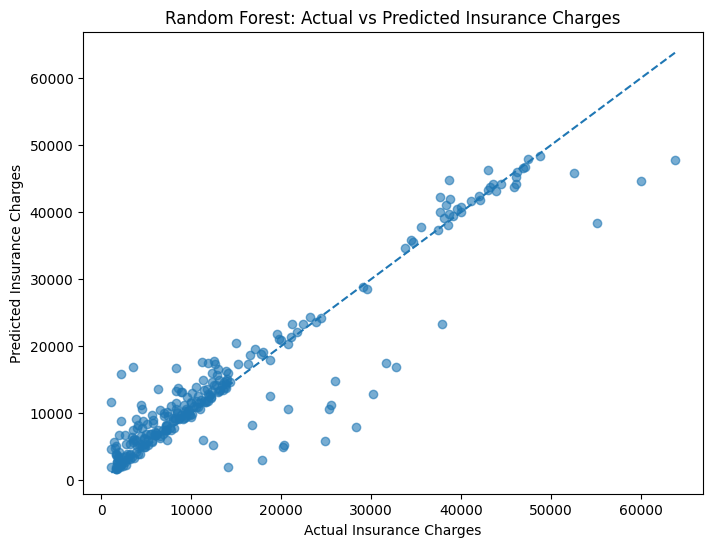

In [107]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, rf_pred, alpha=0.6)

# Perfect prediction reference line
min_value = min(y_test.min(), rf_pred.min())
max_value = max(y_test.max(), rf_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Insurance Charges")
plt.ylabel("Predicted Insurance Charges")
plt.title("Random Forest: Actual vs Predicted Insurance Charges")

plt.show()

In [108]:
final_model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "Test MAE": [mae, rf_mae],
    "Test RMSE": [rmse, rf_rmse],
    "Test R²": [r2, rf_r2],
    "Mean CV R²": [lr_cv.mean(), rf_cv.mean()],
    "CV R² Std": [lr_cv.std(), rf_cv.std()]
})

final_model_comparison.round(4)

,Model,Test MAE,Test RMSE,Test R²,Mean CV R²,CV R² Std
0,Linear Regression,4177.0456,5956.3429,0.8069,0.7467,0.0247
1,Random Forest,2631.9537,4696.3189,0.8800,0.8362,0.0315


## Final Model Evaluation

The two predictive models were evaluated using test-set performance and 5-fold cross-validation.

Random Forest produced lower MAE and RMSE values than Linear Regression and achieved a higher test R² score. It also maintained a higher average R² score during cross-validation.

The Linear Regression model provided useful interpretability through its coefficients, while the Random Forest model captured more complex and nonlinear relationships in the data.

Based on the predictive results obtained in this analysis, the Random Forest model demonstrated stronger predictive performance on this dataset. However, both models contributed useful insights: Linear Regression helped explain the direction and magnitude of relationships, while Random Forest provided improved predictive accuracy.

The findings should be interpreted as associations within the dataset rather than causal relationships.

# Key Findings

The exploratory data analysis and predictive modelling produced several important findings from the insurance dataset.

### 1. Smoking Status and Insurance Charges
Smoking status showed the strongest relationship with insurance charges. Smokers generally had substantially higher charges than non-smokers. This pattern was also reflected in both the Linear Regression coefficients and Random Forest feature importance.

### 2. BMI and Insurance Charges
BMI was another important predictor of insurance charges. The Random Forest model identified BMI as the second most important feature after smoking status, suggesting that differences in BMI contribute meaningfully to the model's predictions.

### 3. Age and Insurance Charges
Age was also associated with insurance charges. Older individuals generally tended to have higher charges, and age was identified as one of the more important predictors by both modelling approaches.

### 4. Number of Children
The number of children contributed to the prediction of insurance charges, although its influence was considerably smaller than smoking status, BMI, and age.

### 5. Sex and Region
Sex and geographical region had relatively small contributions to the predictive models compared with smoking status, BMI, and age.

### 6. Model Performance
Both Linear Regression and Random Forest were able to explain a substantial proportion of the variation in insurance charges.

Linear Regression achieved a test R² score of approximately 0.807, while Random Forest achieved approximately 0.880.

The 5-fold cross-validation results produced average R² scores of approximately 0.747 for Linear Regression and 0.836 for Random Forest.

Overall, the Random Forest model demonstrated stronger predictive performance on this dataset.

# Recommendations

Based on the findings of this analysis, the following recommendations can be made:

1. **Consider Smoking Status in Cost Analysis:**  
   Smoking status was the strongest predictor of insurance charges in the dataset. Insurance cost analysis and forecasting models should therefore account carefully for smoking status.

2. **Include BMI and Age in Predictive Models:**  
   BMI and age were also important predictors. These variables should be retained when developing models for estimating insurance charges.

3. **Use Nonlinear Models Where Appropriate:**  
   Random Forest achieved stronger predictive performance than Linear Regression, suggesting that nonlinear relationships exist between the predictor variables and insurance charges.

4. **Combine Prediction with Interpretability:**  
   Although Random Forest produced better predictive results, Linear Regression remains useful for understanding the direction and approximate magnitude of relationships between individual predictors and insurance charges.

5. **Validate Models Before Deployment:**  
   Before using the model in a real-world insurance setting, it should be validated using additional and more recent datasets representing the intended population.

# Limitations

This project has several limitations that should be considered when interpreting the results:

- The analysis is based on a relatively small dataset and may not represent the wider population.
- Only the variables available in the dataset were considered. Other factors that may influence insurance charges were not included.
- The analysis identifies associations and predictive relationships but does not establish causal relationships.
- Random Forest feature importance indicates how useful variables are for prediction but should not be interpreted as proof that a variable causes higher or lower insurance charges.
- Model performance may change when applied to new populations or datasets collected under different conditions.
- The models were developed for analytical and educational purposes and should not be treated as production-ready insurance pricing systems.

# Conclusion

This project explored the factors associated with medical insurance charges and developed machine learning models for predicting insurance costs.

Exploratory data analysis revealed clear differences in charges across several characteristics, particularly smoking status. BMI and age also showed meaningful relationships with insurance charges.

Two regression models were developed: Linear Regression and Random Forest Regression. Linear Regression provided an interpretable baseline model and achieved an R² score of approximately 0.807 on the test data. Random Forest improved predictive performance, achieving an R² score of approximately 0.880.

Five-fold cross-validation further supported the predictive performance of the models, with average R² scores of approximately 0.747 for Linear Regression and 0.836 for Random Forest.

Feature analysis indicated that smoking status was the most influential predictor in the models, followed primarily by BMI and age.

Overall, the project demonstrates how exploratory data analysis, statistical interpretation, and machine learning can be combined to investigate insurance cost patterns and develop predictive models. The results represent relationships observed within this dataset and should not be interpreted as causal effects.

# Conclusion and Recommendations

## Conclusion

This project investigated the use of machine learning to predict individual medical insurance charges using demographic and lifestyle characteristics such as age, BMI, number of children, sex, smoking status, and region.

Two regression models were developed and evaluated: **Linear Regression** and **Random Forest Regression**.

The Linear Regression model achieved a Test R² score of approximately **0.807**, while the Random Forest model achieved approximately **0.880**. The Random Forest model also produced lower prediction errors, with an MAE of approximately **$2,631.95** and an RMSE of approximately **$4,696.32**, compared with the Linear Regression model's MAE of approximately **$4,177.05** and RMSE of approximately **$5,956.34**.

Five-fold cross-validation provided further evidence of the difference in predictive performance. The Linear Regression model achieved a mean cross-validation R² of approximately **0.747**, while Random Forest achieved approximately **0.836**.

Based on these evaluation results, the **Random Forest Regression model was selected as the final predictive model** for this project.

## Key Findings

The analysis showed that **smoking status was the most influential feature** in predicting insurance charges in the Random Forest model, followed by **BMI and age**. The Random Forest feature-importance analysis assigned smoking status an importance of approximately **0.601**, BMI approximately **0.216**, and age approximately **0.136**.

The results also demonstrate that insurance charges contain relationships that are not fully captured by a simple linear model. Random Forest was able to capture more complex patterns in the data and produced more accurate predictions on the test dataset.

## Recommendations

Based on the findings of this project:

- Machine-learning models such as Random Forest can be considered when predicting insurance charges where relationships between variables may be nonlinear.
- Smoking status, BMI, and age should receive particular attention when investigating the factors associated with variation in insurance charges in this dataset.
- Future work could evaluate additional regression algorithms and perform systematic hyperparameter tuning.
- Additional relevant variables could be incorporated if available to determine whether predictive performance can be improved.
- The model should be validated on additional or external data before being considered for real-world decision-making.

## Final Note

The model developed in this project is intended for educational and analytical purposes. Its predictions represent estimates based on patterns present in the dataset and should not be interpreted as guaranteed insurance costs for individual people.

In [109]:
import os

# Create a folder for project visualisations
os.makedirs("images", exist_ok=True)

print("Images folder created successfully.")

Images folder created successfully.


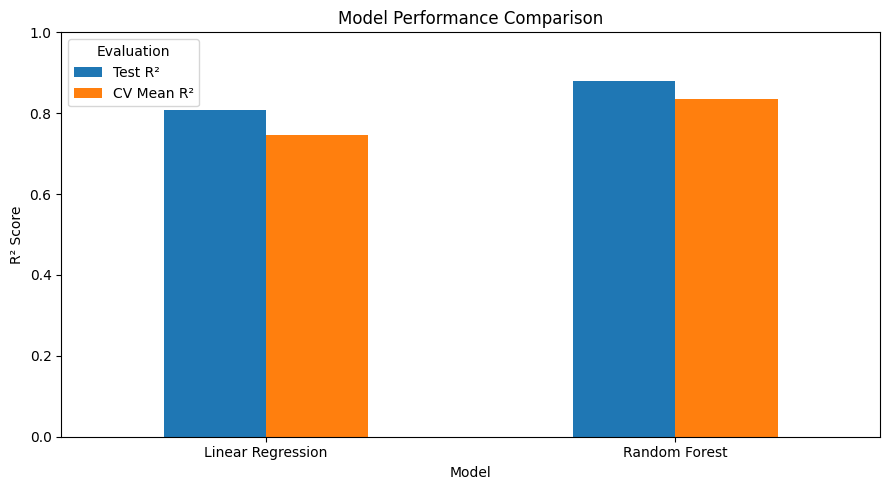

In [110]:
r2_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "Test R²": [r2, rf_r2],
    "CV Mean R²": [lr_cv.mean(), rf_cv.mean()]
})

ax = r2_comparison.set_index("Model").plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Model Performance Comparison")
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Evaluation")
plt.tight_layout()

# Save the chart
plt.savefig(
    "images/model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [111]:
os.path.exists("images/model_performance_comparison.png")

True

In [112]:
print(os.path.abspath("images"))

C:\Users\USER\Medical-Insurance-Cost-Prediction\images


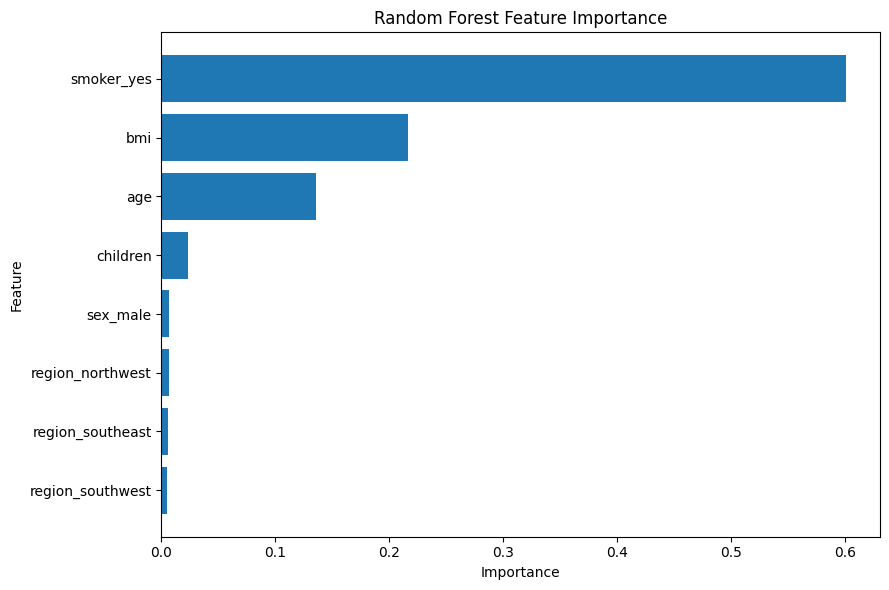

In [113]:
# Random Forest Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(9, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

# Save the chart
plt.savefig(
    "images/random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [114]:
os.path.exists("images/random_forest_feature_importance.png")

True

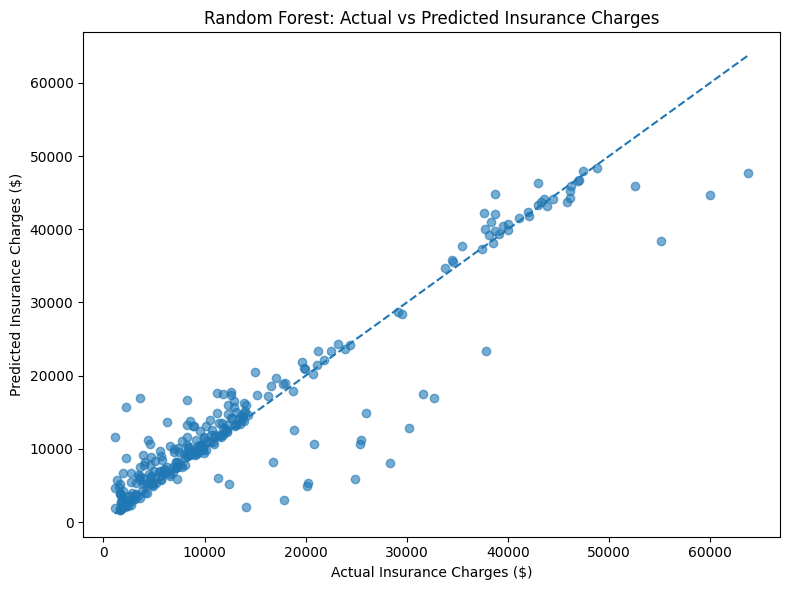

In [115]:
# Random Forest: Actual vs Predicted Insurance Charges

plt.figure(figsize=(8, 6))

plt.scatter(y_test, rf_pred, alpha=0.6)

# Perfect prediction reference line
min_value = min(y_test.min(), rf_pred.min())
max_value = max(y_test.max(), rf_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Random Forest: Actual vs Predicted Insurance Charges")
plt.xlabel("Actual Insurance Charges ($)")
plt.ylabel("Predicted Insurance Charges ($)")
plt.tight_layout()

# Save the chart
plt.savefig(
    "images/random_forest_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [116]:
os.path.exists("images/random_forest_actual_vs_predicted.png")

True

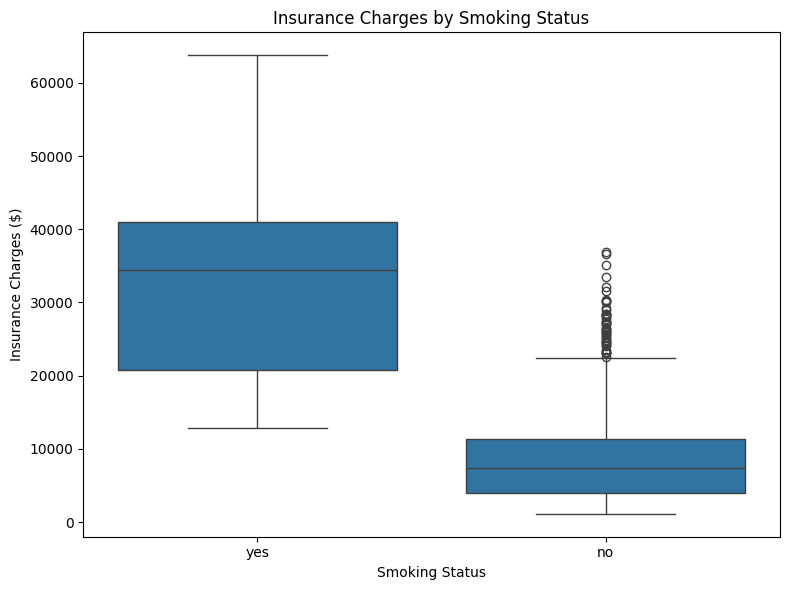

In [117]:
# Import Seaborn
import seaborn as sns

# Smoking Status vs Insurance Charges

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="smoker",
    y="charges"
)

plt.title("Insurance Charges by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Insurance Charges ($)")
plt.tight_layout()

# Save the chart
plt.savefig(
    "images/insurance_charges_by_smoking_status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [118]:
os.path.exists("images/insurance_charges_by_smoking_status.png")

True

In [119]:
import os

project_folder = "Medical-Insurance-Cost-Prediction"

os.makedirs(project_folder, exist_ok=True)
os.makedirs(f"{project_folder}/data", exist_ok=True)
os.makedirs(f"{project_folder}/images", exist_ok=True)

print("Project folders created successfully.")

Project folders created successfully.


In [120]:
print(os.path.abspath(project_folder))

C:\Users\USER\Medical-Insurance-Cost-Prediction\Medical-Insurance-Cost-Prediction


In [121]:
import shutil
import os

image_files = [
    "model_performance_comparison.png",
    "random_forest_feature_importance.png",
    "random_forest_actual_vs_predicted.png",
    "insurance_charges_by_smoking_status.png"
]

for image_file in image_files:
    source = os.path.join("images", image_file)
    destination = os.path.join(
        "Medical-Insurance-Cost-Prediction",
        "images",
        image_file
    )

    shutil.copy2(source, destination)

print("All images copied successfully.")

All images copied successfully.


In [122]:
project_images = os.listdir(
    "Medical-Insurance-Cost-Prediction/images"
)

project_images

['insurance_charges_by_smoking_status.png',
 'model_performance_comparison.png',
 'random_forest_actual_vs_predicted.png',
 'random_forest_feature_importance.png']

In [123]:
plt.savefig(
    "images/model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [129]:
import os

project_files = []

for root, dirs, files in os.walk("."):
    for file in files:
        project_files.append(os.path.join(root, file))

for file in project_files:
    print(file)

.\CapstoneProject.ipynb
.\medical_insurance_cleaned.csv
.\README.md
.\requirements.txt
.\.ipynb_checkpoints\CapstoneProject-checkpoint.ipynb
.\data\medical_insurance_cleaned.csv
.\data\.ipynb_checkpoints\medical_insurance_cleaned-checkpoint.csv
.\images\insurance_charges_by_smoking_status.png
.\images\model_performance_comparison.png
.\images\random_forest_actual_vs_predicted.png
.\images\random_forest_feature_importance.png
.\images\.ipynb_checkpoints\model_performance_comparison-checkpoint.png
.\Medical-Insurance-Cost-Prediction\images\insurance_charges_by_smoking_status.png
.\Medical-Insurance-Cost-Prediction\images\model_performance_comparison.png
.\Medical-Insurance-Cost-Prediction\images\random_forest_actual_vs_predicted.png
.\Medical-Insurance-Cost-Prediction\images\random_forest_feature_importance.png
